In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
import pandas as pd
import os
from IPython.display import display, Math, clear_output
import matplotlib.pyplot as plt 

from Quantum_Simulation.Floquet import Floquet_Simulation
from Signal_Analysis.SignalAnalysis import Fourier_Transform, Atomic_Norm_Minimization

import json

# 1 Set Connection

In [2]:
with open("secret.json") as f:
    cfg = json.load(f)

QiskitRuntimeService.save_account(
    token=cfg["TOKEN"],
    instance=cfg["INSTANCE"],
    overwrite=True
)

service = QiskitRuntimeService()

# List accessible real backends
print("Avaiable backends with gates")
backends = service.backends(simulator=False, operational=True)

for b in backends:
    name = b.name
    ops = set(getattr(b.target, "operation_names", []))
    if "cz" in ops:  # crude but useful sign for Heron-style target
        print(name, sorted(list(ops))[:10], "...")


Avaiable backends with gates
ibm_fez ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...
ibm_torino ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...
ibm_marrakesh ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...
ibm_kingston ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x'] ...


## 1.1 Choice of hardware and Noise characterization

Backend: ibm_fez
Qubits: 156



Metric,Min,Mean,Median,Max
T1 (µs),10.46,149.6,147.6,294.6
T2 (µs),5.715,107.7,106.0,251.3
Readout error,3.91e-03,0.030,0.015,0.435


Gate,Metric,Min,Mean,Median,Max
rz,error,0,0,0,0
rz,duration (ns),0,0,0,0
sx,error,1.26e-04,6.78e-03,2.87e-04,1.000
sx,duration (ns),24.00,24.00,24.00,24.00
x,error,1.26e-04,6.78e-03,2.87e-04,1.000
x,duration (ns),24.00,24.00,24.00,24.00
measure,error,3.91e-03,0.030,0.015,0.435
measure,duration (ns),1560.0,1560.0,1560.0,1560.0
cz,error,1.36e-03,0.027,2.57e-03,1.000
cz,duration (ns),68.00,68.23,68.00,88.00


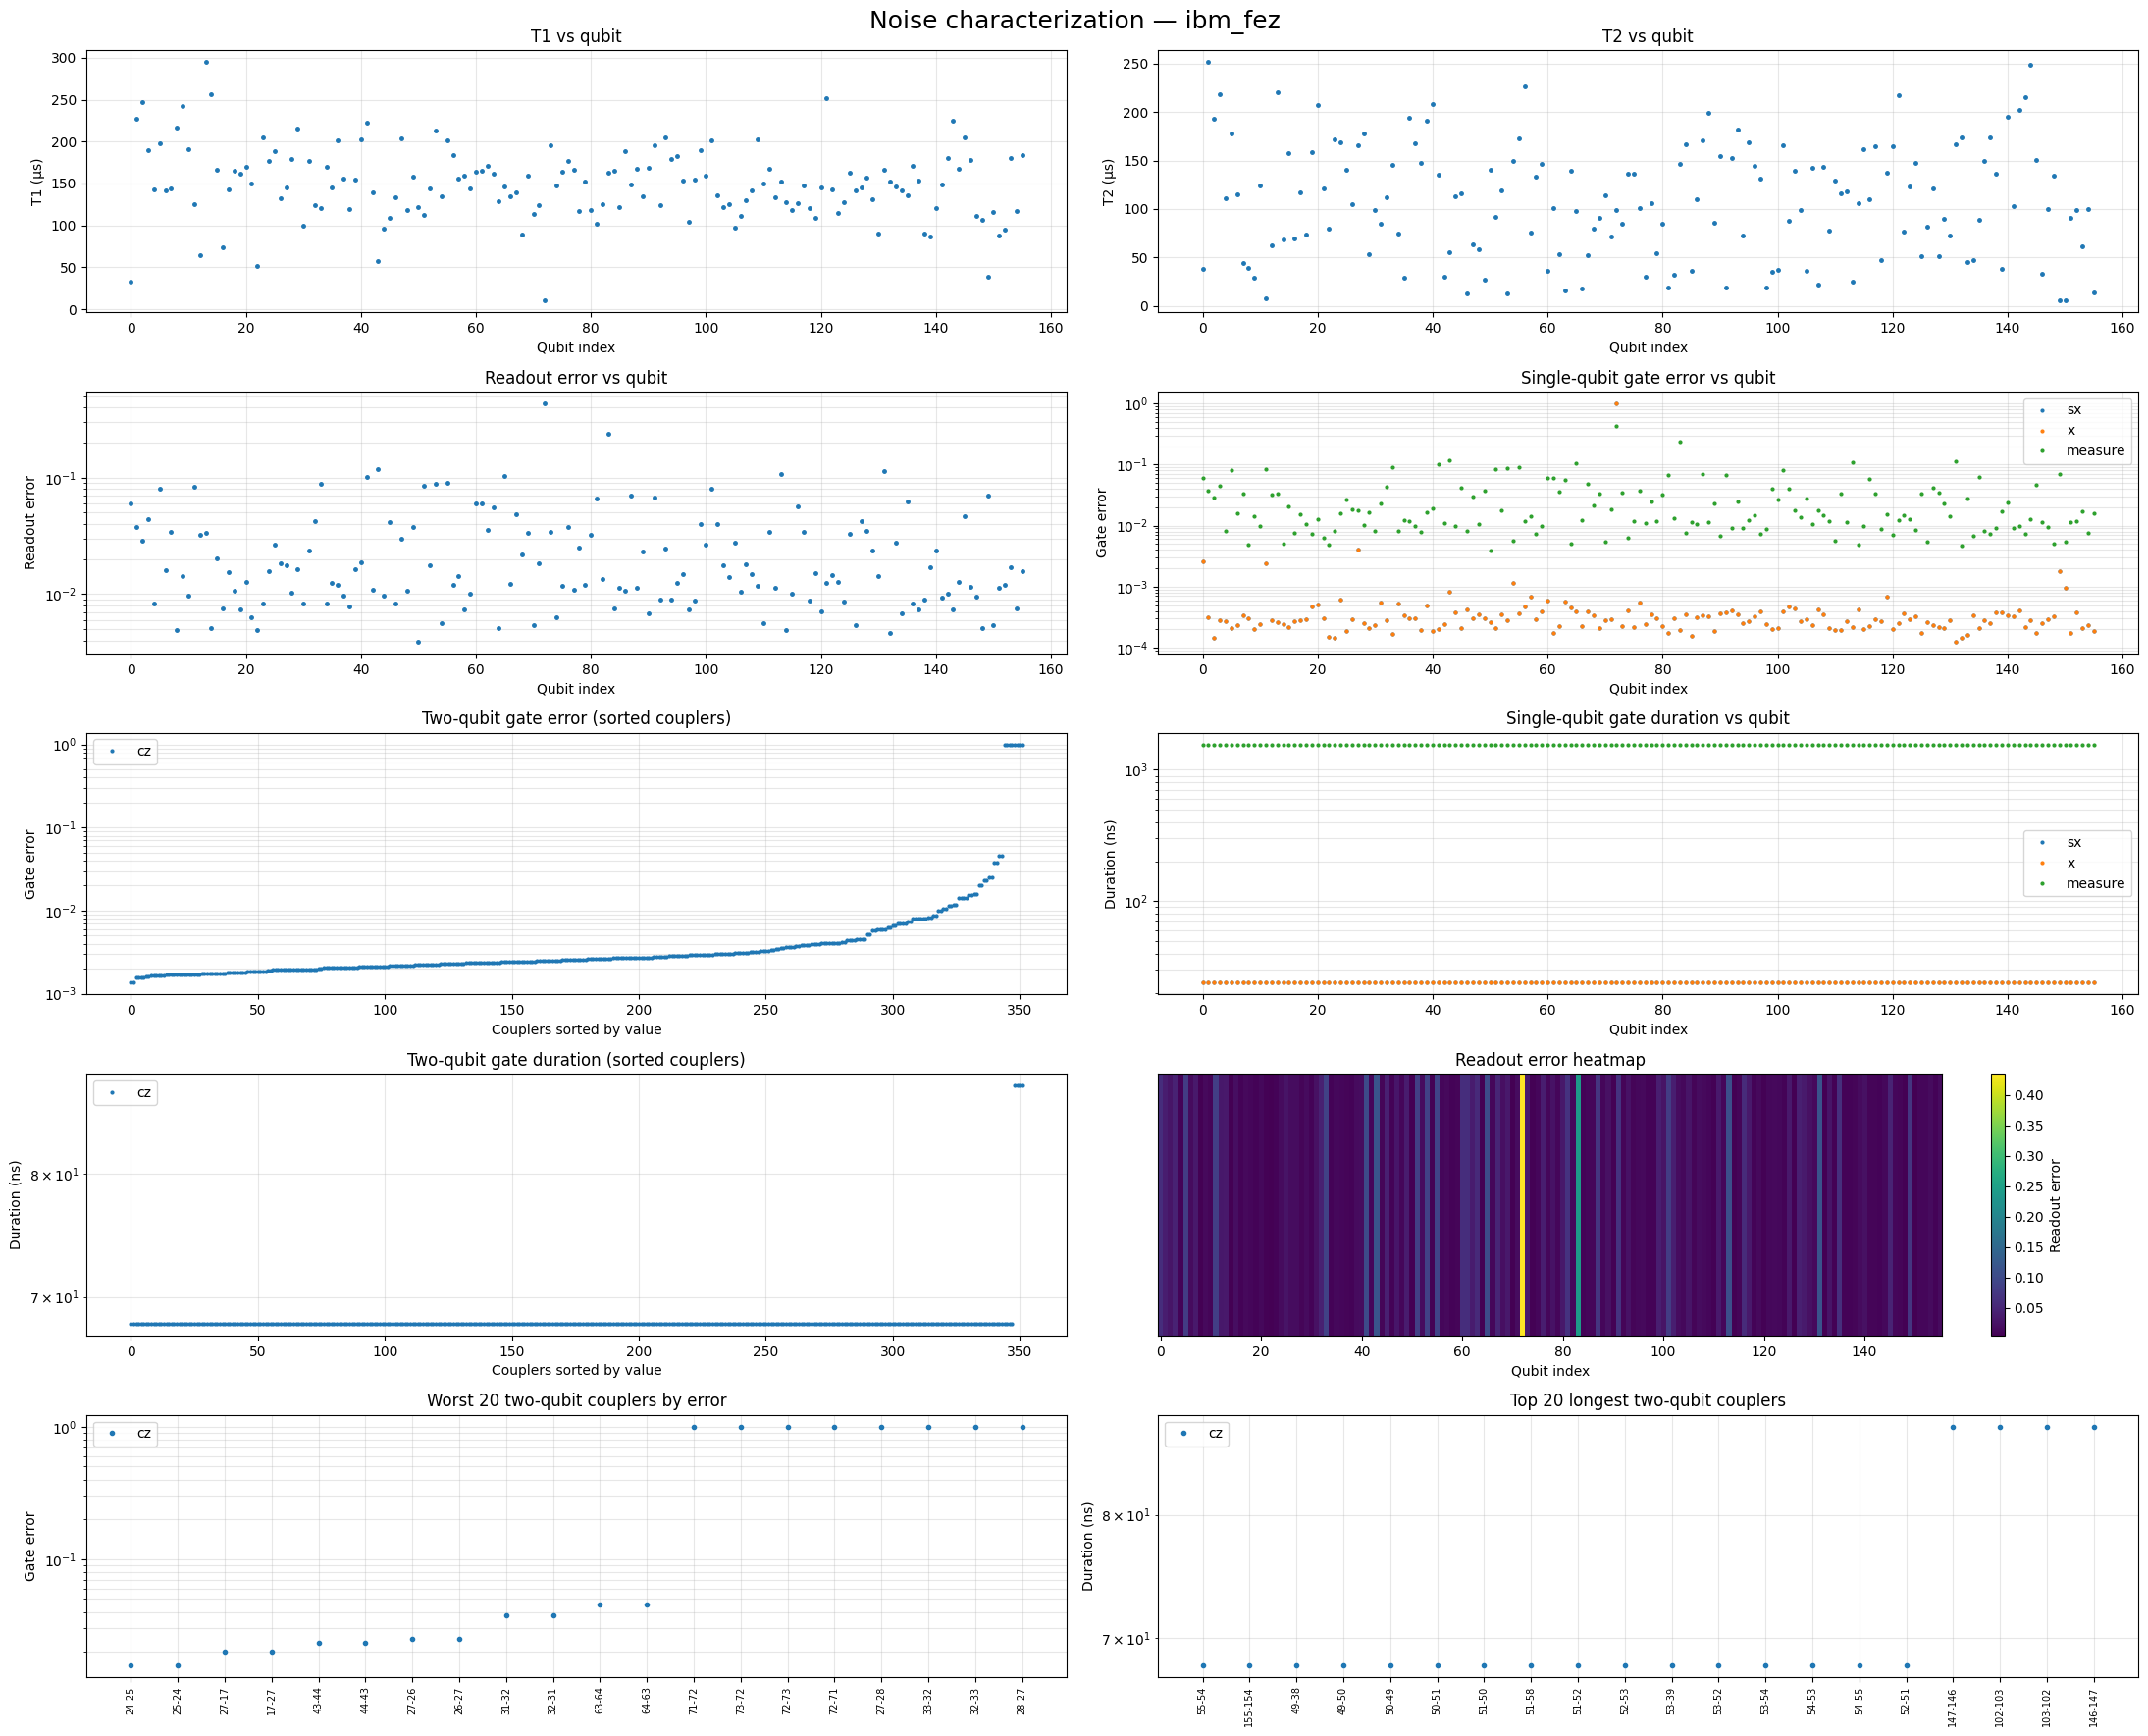

In [3]:
from utils.NoiseVisualization import BackendNoiseVisualizer

backend = service.backend("ibm_fez") # Choose avaiable processor
viz = BackendNoiseVisualizer(
    backend,
    gate_names=["rz", "sx", "x", "measure", "ecr", "cx", "cz"],
    figsize=(22, 18)
)

viz.print_summary()
print("\n \n ")
viz.plot_dashboard(top_k_couplers=20)

# 2 Two-level system driven by Circular Polarized Field

Given the following hamiltonian 
$$
H(t) = \frac{\omega_0}{2} Z + \Omega \left( X \cos(\omega t) + Y \sin(\omega t) \right)
$$

We can compute analytically the quasienergies
$$
\epsilon_{\pm} =
\frac{\omega}{2}
\pm
\sqrt{
\left(\frac{\omega}{2}-\frac{\omega_0}{2}\right)^2
+
\left(\frac{\Omega}{2}\right)^2
}
$$

The latter are defined $\mathrm{mod}\,\omega$, choosing 
$\epsilon_{\pm} \in \left[-\frac{\omega}{2},\,\frac{\omega}{2}\right]$, 
we see that 
$\epsilon_- = -\epsilon_+ \; (\mathrm{mod}\,\omega)$.

We define $h_1 := \frac{\omega _0}{2}, \; h_2:= \Omega$, while T is the period of the Hamiltonian

In this section we choose $h_1 = 1, \; h_2 = \sqrt{2}, \; T = 1$

## 2.1 Analytical distribution

Quasienergies computed analytically:


<IPython.core.display.Math object>

Period probability distribution: 10.923656334979848


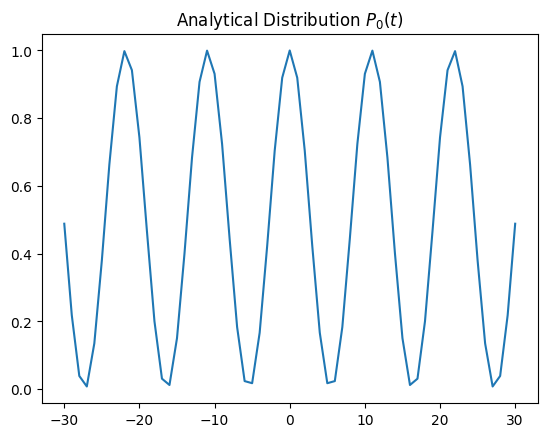

In [4]:
h1, h2, T = 1, np.sqrt(2), 1
num_points = 60
# Probability distribution generated for t in [- num_points * T, num_points * T] with spacing dt = T

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

print("Quasienergies computed analytically:")
display(Math(r"\epsilon_{\pm} = \pm %.5f" % (epsilon)))
print(f"Period probability distribution: {2 * np.pi / epsilon}")

plt.title(f"Analytical Distribution $P_0(t)$")
t = T * np.arange(-int(num_points / 2), int(num_points / 2) + 1, 1)
P_analytical = (1 + np.cos(epsilon * t)) / 2
plt.plot(t, P_analytical)
plt.show()

### 2.1.1 Study of the reconstruction error with DFT and ANM

Given the analytical probability distribution
$$P_0(t)= \frac{1}{2} (1 + cos(\epsilon t))$$

with $\epsilon \approx 0.57519 $

We generate the analytical distribution in a given time window then use DFT and ANM to recover $\epsilon$.

For varying rent time windows we can compute the reconstruction error  


$$\frac{|\epsilon_{reconstructed} - \epsilon }{\epsilon}|$$

The goal is to identify the minimum time window for which DFT and ANM achieves a reconstruction with an error less than $10\%$.


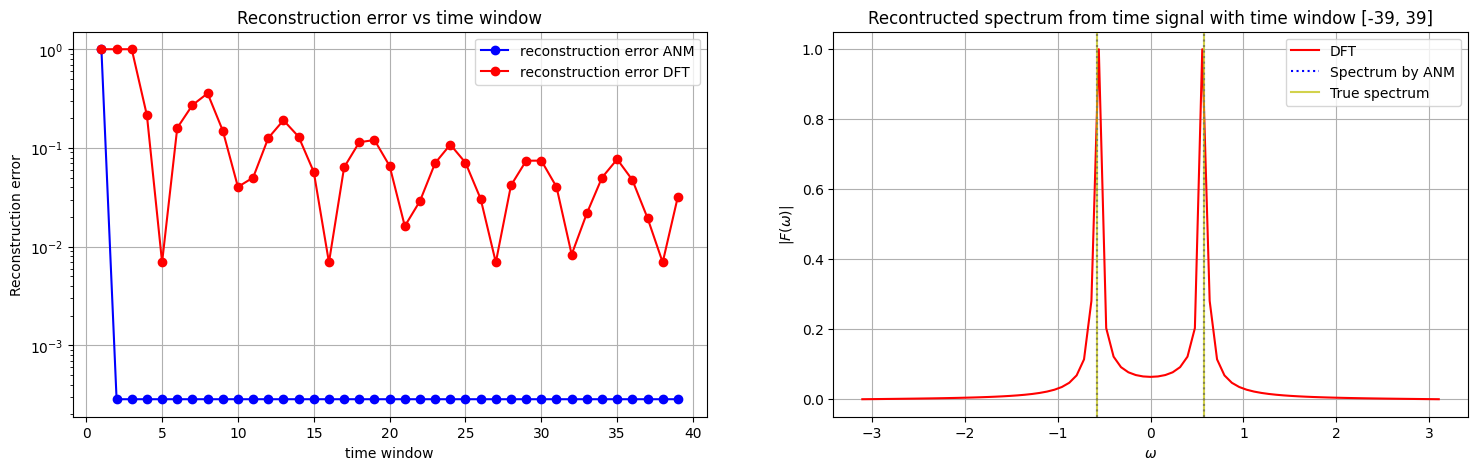

In [5]:
# Here reconstruction error is studied with time window varying from [-T, T] to [-T * max_time_window, T * max_time_window]
# In the plot on the left reconstruction error is showed vs time window, 
# while on the right spectrum reconstructed for that given time window

max_time_window = 40    # Max Time window to choose
step_size_time_window = 1 # Increment per loop

error_list_DFT = []
error_list_ANM = []
times = np.arange(1, max_time_window, step_size_time_window) * T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + step_size_time_window)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical - 1/2)
    epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=1e-5, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
    error_list_ANM.append(np.abs(epsilon - epsilon_ANM) / epsilon)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()
    ax2.clear()

    ax1.plot(times[:i + 1], error_list_ANM, 'bo-', label="reconstruction error ANM")
    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
    ax2.set_xlabel('$\omega$')
    ax2.set_ylabel('$|F(\omega)|$')
    ax2.set_title(f"Recontructed spectrum from time signal with time window [{-time_window}, {time_window}]")
    ax2.axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
    ax2.axvline(x=-epsilon_ANM, color = 'b', ls = ":")
    ax2.axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
    ax2.axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)

plt.close(fig)


We see that ANM achieves a good reconstruction error (0.02) with time window [-2, 2], going beyond the Fourier limit, as $2 < \frac{\pi}{\epsilon} \approx 5 $.

For [-3, 3] ANM converge towards an error of $3 \times 10^{-4}$.
DFT error decreased with an oscillatory behaviour and to oscillate around $10^{-4}$ it needs a time window of about 2000.(See next cell)

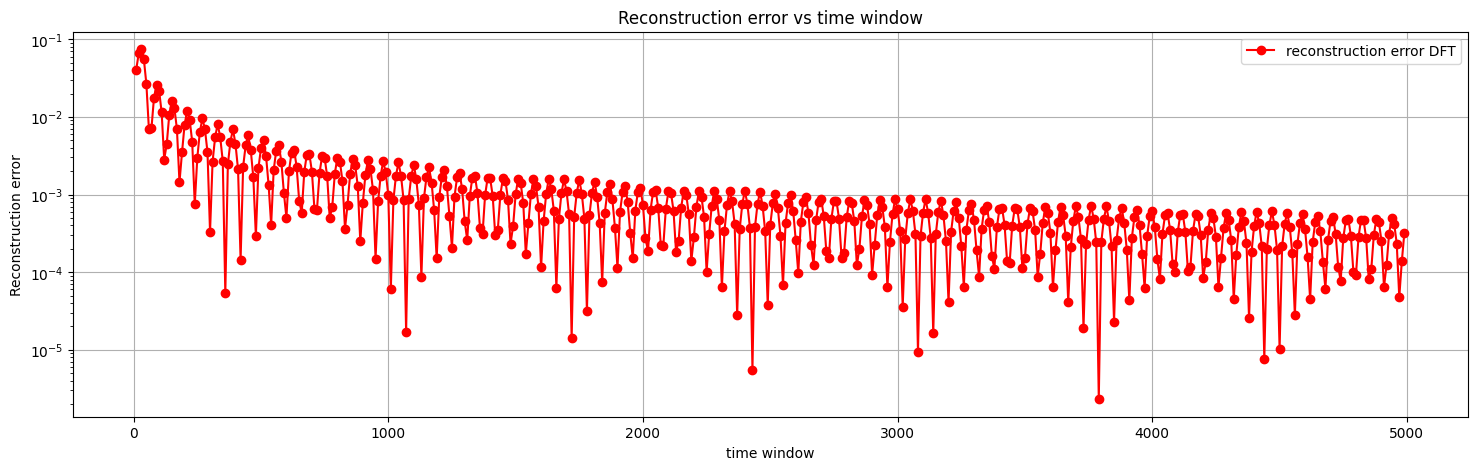

In [6]:
# Static plot Reconstruction error vs time window for DFT

max_time_window = 5000    # Max Time window (in periods T) to choose
step_size_time_window = 10  # Increment (in periods T) per loop

error_list_DFT = []
times = np.arange(step_size_time_window, min(max_time_window, max_time_window + step_size_time_window), step_size_time_window) * T

fig, ax1 = plt.subplots(figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + 1)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()

    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    clear_output(wait=True)
    display(fig)

plt.close(fig)


In conclusion the minimum time window to achieve an error less than $10\%$  for ANM is $[-2, 2]$ with error 0.002 

while for DFT is $[-5, 5]$ with error $0.006$

## 2.2 Trotter Error Analysis (No quantum noise)

### 2.2.1 Relative MAE Error

We study the relative MAE error between the probability obtained from quantum simlation with Trotter formulas and the analytical one.

In [21]:
T = 1; h1 = 1; h2=np.sqrt(2)
FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
simulator = AerSimulator()


def get_MAE_Trotter_error(t, Order_formula, num_Trotter_steps, shots=10 ** 6):
    U = FS_noisless.evolution_operator(t_f=t, t_0=0, Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, Polarization="Circular")
    qc = FS_noisless.SWAP_test(coeff=[1, 0], U=U)
    qc = transpile(qc, backend=simulator)
    job = simulator.run(qc, shots=shots)
    Prob = job.result().get_counts().get('0', 0) / shots
    P_analytical = (1 + np.cos(t * FS_noisless.quasi_energy_circular())) / 2
    return abs(Prob - P_analytical) / P_analytical

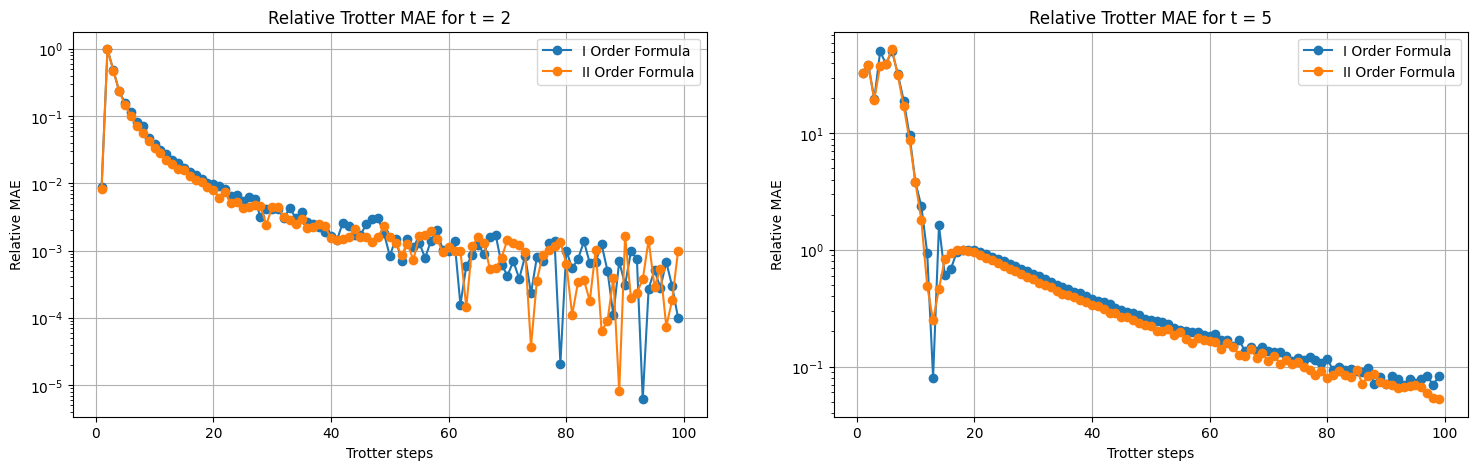

t=2 Relative MAE is less than 10% for Trotter steps in [ 1  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77
 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99] and I Order Formula 

t=2 Relative MAE is less than 10% for Trotter steps in [ 1  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76
 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99] and II Order Formula 

t=5 Relative MAE is less than 10% for Trotter steps in [13 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99] and I Order Formula 

t=5 Relative MAE is less than 10% for Trotter steps in [77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99] and

In [22]:
# Error studied in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])

Max_num_Trotter_steps = 100       
delta_num_Trotter_steps = 1

array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
t_2_MAE_error_list = [[], []]
t_5_MAE_error_list = [[], []]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    t_2_MAE_error_list[0].append(get_MAE_Trotter_error(t=2, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_2_MAE_error_list[1].append(get_MAE_Trotter_error(t=2, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[0].append(get_MAE_Trotter_error(t=5, Order_formula="First", num_Trotter_steps=num_Trotter_steps))
    t_5_MAE_error_list[1].append(get_MAE_Trotter_error(t=5, Order_formula="Second", num_Trotter_steps=num_Trotter_steps))

    ax1.clear()
    ax2.clear()

    ax1.set_title(f"Relative Trotter MAE for t = 2")
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[0], '-o', label='I Order Formula')
    ax1.plot(array_num_Trotter_steps[:i + 1], t_2_MAE_error_list[1], '-o', label='II Order Formula')
    ax1.set_yscale('log')
    ax1.set_xlabel("Trotter steps")
    ax1.set_ylabel("Relative MAE")
    ax1.grid(True)
    ax1.legend()

    ax2.set_title(f"Relative Trotter MAE for t = 5")
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[0], '-o', label='I Order Formula')
    ax2.plot(array_num_Trotter_steps[:i + 1], t_5_MAE_error_list[1], '-o', label='II Order Formula')
    ax2.set_yscale('log')
    ax2.set_xlabel("Trotter steps")
    ax2.set_ylabel("Relative MAE")
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

print(f"t=2 Relative MAE is less than 10% for Trotter steps in {array_num_Trotter_steps[np.array(t_2_MAE_error_list[0]) < 0.1]} and I Order Formula \n")
print(f"t=2 Relative MAE is less than 10% for Trotter steps in {array_num_Trotter_steps[np.array(t_2_MAE_error_list[1]) < 0.1]} and II Order Formula \n")
print(f"t=5 Relative MAE is less than 10% for Trotter steps in {array_num_Trotter_steps[np.array(t_5_MAE_error_list[0]) < 0.1]} and I Order Formula \n")
print(f"t=5 Relative MAE is less than 10% for Trotter steps in {array_num_Trotter_steps[np.array(t_5_MAE_error_list[1]) < 0.1]} and II Order Formula \n")

We see that for t=2 (reasonable time window for ANM) the relative error converges to less than $10\%$ for 7 Trotter steps and I Order Formula and for 6 Trotter steps and II Order fromula.

While for t = 5 (DFT), the relative error converges to less than $10\%$ for 83 Trotter steps and I Order Formula and for 86 Trotter steps and II

### 2.2.2 Study the Reconstruction error DFT and ANM with Trotter Error

We repeat the analasys done in paragraph 2.1.1, but this time we extract the quasienergies from the probability distribution obtained by Quantum Simulation with Trotter Formulas and

fix the time window (t=2 for ANM and t=5 for DFT), but vary the number of Trotter steps.

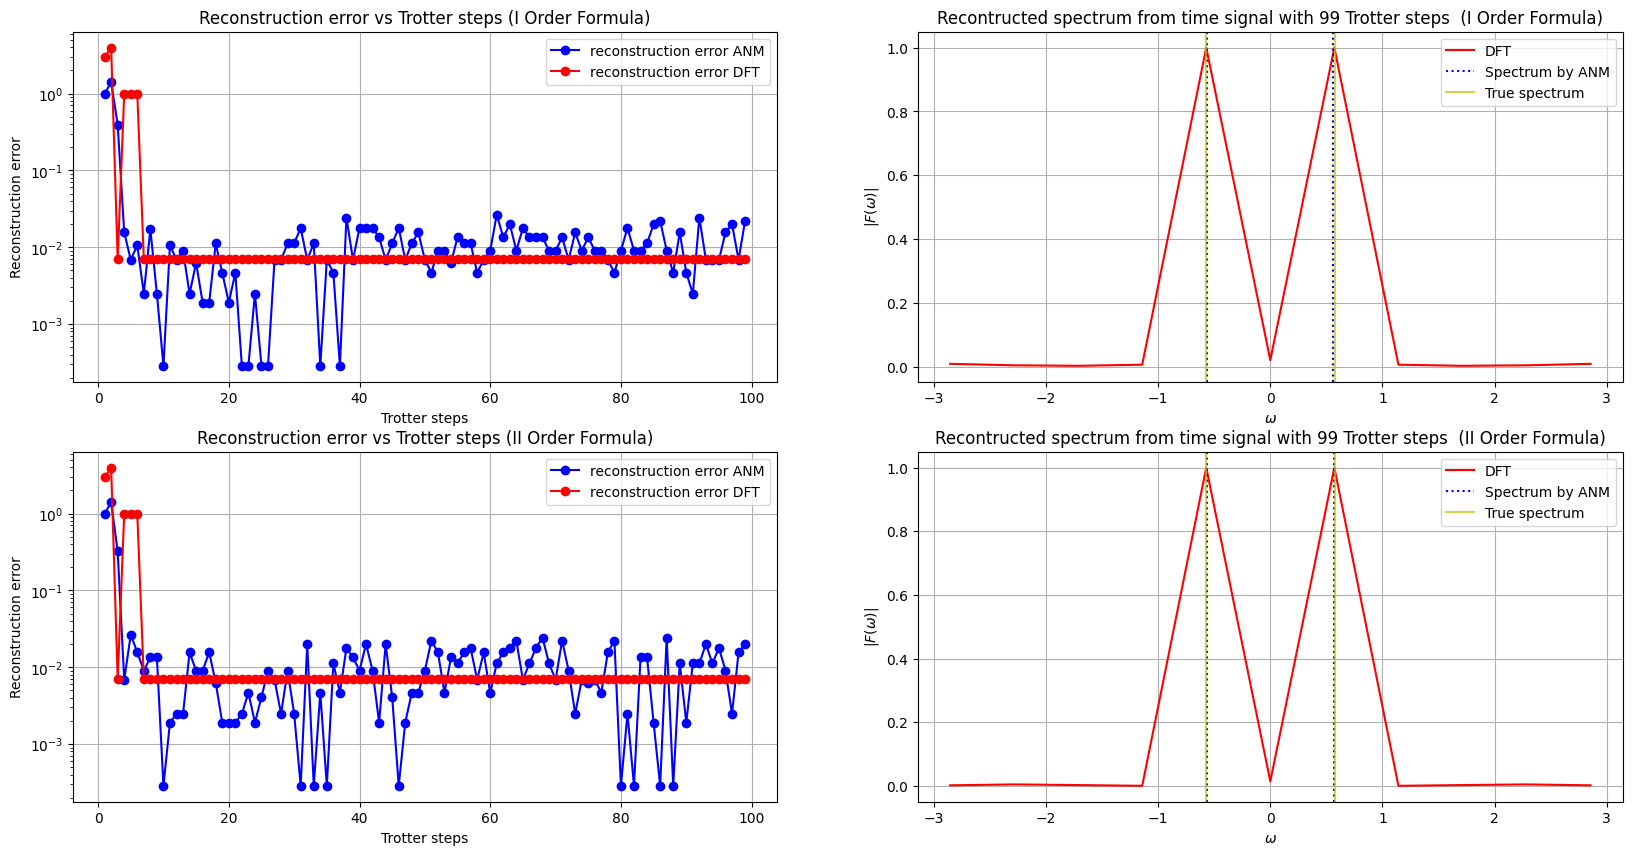

In [23]:
# Error studied in range [delta_num_Trotter_steps, Max_num_Trotter_steps] with increments of delta_num_Trotter_steps
Max_num_Trotter_steps = 100       
delta_num_Trotter_steps = 1


array_num_Trotter_steps = np.arange(delta_num_Trotter_steps, Max_num_Trotter_steps, delta_num_Trotter_steps)
num_points_t_2 = 5
num_points_t_5 = 11
error_list_DFT_Trotter = [[], []]
error_list_ANM_Trotter = [[], []]

FS_noisless = FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()


fig, axes = plt.subplots(2, 2, figsize=(20, 10))
for i, num_Trotter_steps in enumerate(array_num_Trotter_steps):
    [ax.clear() for ax in axes.flatten()]
    for j, Order_formula in enumerate(["First", "Second"]):
        fname_t_2 = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
        fname_t_5 = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order={Order_formula}_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"
        if not os.path.exists(fname_t_2):
            FS_noisless.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_2)
        time_t_2, P_t_2 = np.loadtxt(fname_t_2, unpack=True)
        if not os.path.exists(fname_t_5):
            FS_noisless.get_distribution0(Order_formula=Order_formula, num_Trotter_steps=num_Trotter_steps, num_points=num_points_t_5)
        time_t_5, P_t_5 = np.loadtxt(fname_t_5, unpack=True)

        DFT, ANM = Fourier_Transform(time_t_5, P_t_5 - 1/2), Atomic_Norm_Minimization(time_t_2, P_t_2 - 1/2)
        lam = max(4 * 2.25 / (num_Trotter_steps ** 2), 0.02)   #0.025
        epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=lam, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
        error_list_ANM_Trotter[j].append(np.abs(epsilon - epsilon_ANM) / epsilon)
        result_DTF = DFT.get_DFT(plot=False)
        epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
        error_list_DFT_Trotter[j].append(np.abs(epsilon - epsilon_DFT) / epsilon)

 

        ax1 = axes[:,0]
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_ANM_Trotter[j], 'bo-', label="reconstruction error ANM")
        ax1[j].plot(array_num_Trotter_steps[:i + 1], error_list_DFT_Trotter[j], 'ro-', label="reconstruction error DFT")
        ax1[j].set_yscale('log')
        ax1[j].set_xlabel("Trotter steps")
        ax1[j].set_ylabel("Reconstruction error")
        ax1[j].set_title(f"Reconstruction error vs Trotter steps ({'I' * (j + 1)} Order Formula)")
        ax1[j].legend()
        ax1[j].grid(True)

        ax2 = axes[:,1]
        ax2[j].plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
        ax2[j].set_xlabel(r'$\omega$')
        ax2[j].set_ylabel(r'$|F(\omega)|$')
        ax2[j].set_title(f"Recontructed spectrum from time signal with {num_Trotter_steps} Trotter steps  ({'I' * (j + 1)} Order Formula)")
        ax2[j].axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
        ax2[j].axvline(x=-epsilon_ANM, color = 'b', ls = ":")
        ax2[j].axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
        ax2[j].axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
        ax2[j].grid(True)
        ax2[j].legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)
    [ax.clear() for ax in axes.flatten()]

plt.close(fig)

For the choice of the hyperparameter we recall that for Gaussian noise with std 
$\sigma$

$\lambda \sim \sigma \sqrt{n \log n}$
with $n$ being the size of the signal

The error is characterized by two regimes:
one in which Trotter error is dominant and the second where statistical noise is dominant, with relative fluctuations of $10^{-2}$ (having choosen $10^{-4}$ shots).

For the first regime, we use an approximate model, noticing that Trotter error decreases quadratically with Trotter steps for both formulas(see paragraph 2.2.1)
starting from 2 Trotter steps where relative MAE is 1 for t = 2.
Clearly this is an upper bound, as the error is maximum towards the maximum time window.

In the statistical regime, the $\sigma < 0.01 $.

Putting the two results together, after some tuning we have found that a suitable choice of 
$\lambda$

$$ \lambda(N_{\text{TrotterSteps}}) = \max (\frac{9}{N_{\text{TrotterSteps}}^2}, 0.02 ) $$


We see that after seven Trotter DFT error converges to 0.007, while ANM error oscillated around it and with a proper choice of $\lambda$ can go below 0.001.
However, if the goal is to use the minimum number of Trotter steps to recover the quasienergies with an error smaller than $10 \% $ then for this Hamiltonian in absence of quantum noise ANM does not provide an advantage.
In fact DFT with 3 Trotter steps achieve an error of 0.007, while ANM about 0.01 even tuning the hyperparameter $\lambda$ as we show in next cell.

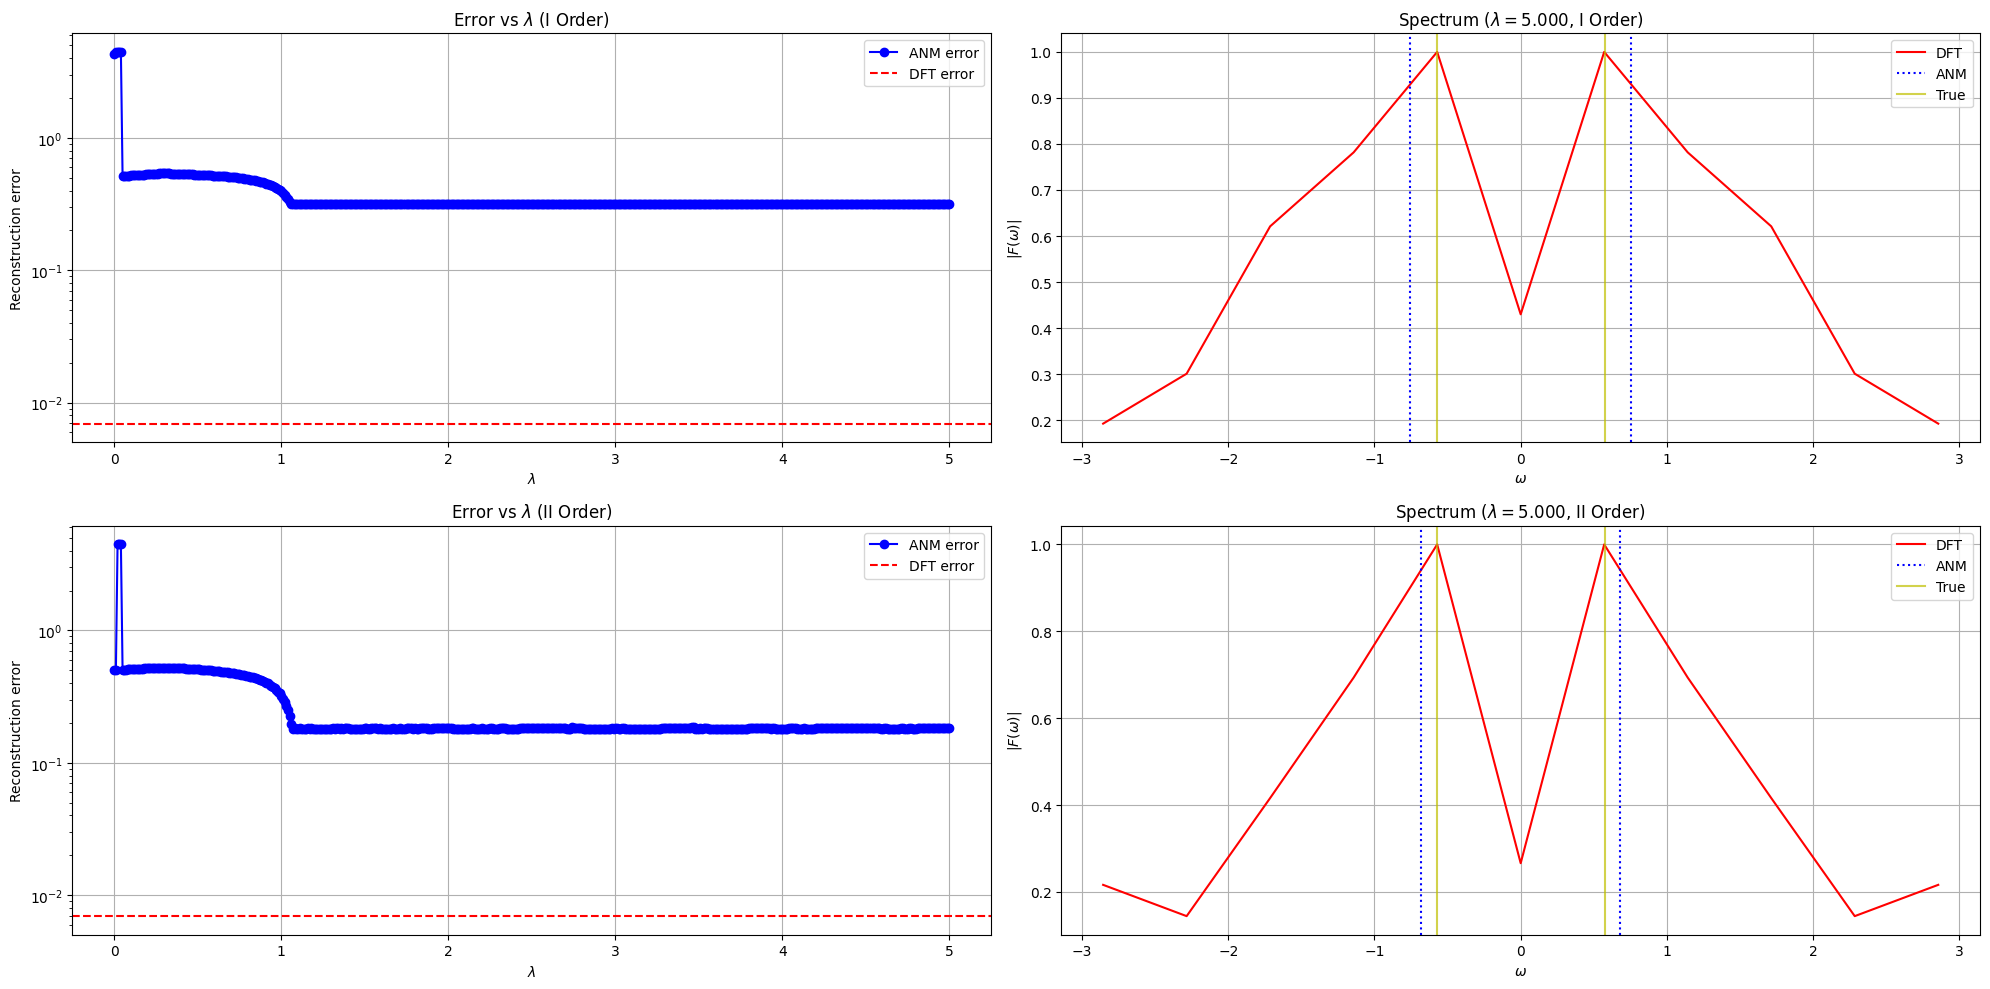

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

num_Trotter_steps = 3
lam_values = np.linspace(0., 5, 501)

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

error_list_ANM = [[], []]

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

fname_t_2_first = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=First_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
fname_t_2_second = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=Second_t_MAX=2_Trotter_steps={num_Trotter_steps}.txt"
fname_t_5_first = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=First_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"
fname_t_5_second = f"Files/QuantumSimulation_Circular_Polarization_T={T}_Order=Second_t_MAX=5_Trotter_steps={num_Trotter_steps}.txt"

time_t_2_first, P_t_2_first = np.loadtxt(fname_t_2_first, unpack=True)
time_t_2_second, P_t_2_second = np.loadtxt(fname_t_2_second, unpack=True)
time_t_5_first, P_t_5_first = np.loadtxt(fname_t_5_first, unpack=True)
time_t_5_second, P_t_5_second = np.loadtxt(fname_t_5_second, unpack=True)

DFT_first = Fourier_Transform(time_t_5_first, P_t_5_first - 1/2)
result_DFT_first = DFT_first.get_DFT(plot=False)
epsilon_DFT_first = np.abs(result_DFT_first[0][np.argmax(result_DFT_first[1])])
error_DFT_first = np.abs(epsilon - epsilon_DFT_first) / epsilon

DFT_second = Fourier_Transform(time_t_5_second, P_t_5_second - 1/2)
result_DFT_second = DFT_second.get_DFT(plot=False)
epsilon_DFT_second = np.abs(result_DFT_second[0][np.argmax(result_DFT_second[1])])
error_DFT_second = np.abs(epsilon - epsilon_DFT_second) / epsilon

error_DFT = [error_DFT_first, error_DFT_second]
result_DFT_all = [result_DFT_first, result_DFT_second]

for i, lam in enumerate(lam_values):
    for ax in axes.flatten():
        ax.clear()

    for j, Order_formula in enumerate(["First", "Second"]):
        if Order_formula == "First":
            ANM = Atomic_Norm_Minimization(time_t_2_first, P_t_2_first - 1/2)
            result_DFT = result_DFT_all[0]
        else:
            ANM = Atomic_Norm_Minimization(time_t_2_second, P_t_2_second - 1/2)
            result_DFT = result_DFT_all[1]

        epsilon_ANM = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=lam, plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
        error_list_ANM[j].append(np.abs(epsilon - epsilon_ANM) / epsilon)

        ax_left = axes[j, 0]
        ax_left.plot(lam_values[:i + 1], error_list_ANM[j], 'bo-', label="ANM error")
        ax_left.axhline(y=error_DFT[j], color='r', ls='--', label="DFT error")
        ax_left.set_yscale('log')
        ax_left.set_xlabel(r'$\lambda$')
        ax_left.set_ylabel("Reconstruction error")
        ax_left.set_title(f"Error vs $\\lambda$ ({'I' * (j + 1)} Order)")
        ax_left.grid(True)
        ax_left.legend()

        ax_right = axes[j, 1]
        ax_right.plot(result_DFT[0], result_DFT[1], 'r', label="DFT")
        ax_right.axvline(x=epsilon_ANM, color='b', ls=':', label="ANM")
        ax_right.axvline(x=-epsilon_ANM, color='b', ls=':')
        ax_right.axvline(x=epsilon, color='y', ls='-', alpha=0.7, label="True")
        ax_right.axvline(x=-epsilon, color='y', ls='-', alpha=0.7)
        ax_right.set_xlabel(r'$\omega$')
        ax_right.set_ylabel(r'$|F(\omega)|$')
        ax_right.set_title(rf"Spectrum ($\lambda={lam:.3f}$, {'I' * (j + 1)} Order)")
        ax_right.grid(True)
        ax_right.legend()

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)

plt.close(fig)

We see that ANM reconstruction error for time window 2 and 3 Trotter steps, II Order Formula, converges towards 0.2, 

while DFT using a time window 5 and same Trotter steps goes below 0.01.